Hana Yabuki

# Directed forgetting in visual working memory

## Background

Forgetting has a negative reputation, and we tend to focus on improving our ability to remember items. However, for dealing with daily problems, such as holding a shopping list in mind, we utilize a mechanism known as working memory. Working memory is limited in capacity, meaning that the information maintained in working memory must be relevant to the task at hand. This requires its contents to be flexibly removed and updated according to task demands. Directed forgetting - the targeted removal of items from working memory - allows us to accomplish this by dropping irrelevant memoranda and storing relevant information in working memory. Traditionally, working memory process information along feature-specific dimensions. For instance, visual representation of memoranda is localized to visual working memory, verbal working memory for words and sentences, and auditory working memory for sound cues. Understanding the mechanisms of directed forgetting will enable us to harness the insights into creating dynamic, task-centered displays that update and reflect concurrent task goals. By creating displays that enable effects such as the facilitative effect of directed forgetting, we ensure that the user will be able to focus and maintain critical, relevant information, rather than hold on to outdated information - thereby cluttering working memory.

Directed forgetting has been extensively studied within verbal working memory (Fawcett & Taylor, 2012; Festini & Reuter-Lorenz, 2013; Popov et al., 2019) using word lists or word pairs. Due to the semantic nature of test items, performance examining word recognition on directed forgetting paradigms are more likely to draw on familiarity with test items, i.e., words. However, familiarity with words is driven directly by frequency of exposure to them, where each encounter is stored over time within long term memory. This intuition is supported by work published by Popov and Reder (2019), where the authors proposed that word familiarity and cumulative to-be-forgotten trials depleted working memory resources over the duration of multiple word pairs. The lengthy timecourse of working memory resource depletion in their study likely reflects the outsourcing of memoranda to long term memory via verbal working memory.

The nature of visual working memory, however, operates via a shorter timecourse, with limited capacity for visual representations. In order to ensure that working memory load is constrained to visual working memory, experimental paradigms rely on item-context binding, where the spatial location of the probe must be preserved alongside its content. Within visual working memory literature, directed forgetting is defined as the unlearning or the unbinding of an item from its context (Ecker et al., 2014). Context can refer to the spatial location or temporal sequence of a test item. Burgeoning research has examined the nature of directed forgetting within visual working memory (Dames & Oberauer, 2022; Ecker et al., 2014; Lewis‐Peacock et al., 2018; Oberauer, 2018; Oberauer & Lewandowsky, 2014) via removal paradigms. However, given the nascent literature, the present work sought to replicate benefits of directed forgetting within a novel visual working memory paradigm - specifically the directed forgetting effect, and the facilitative effect of ‘forget’ conditions.  

In order to understand the directed forgetting effect and the facilitative effect, I will first explain the study’s methods. The study used in this final project is a removal paradigm by Dames and Oberauer (2022). Participants were presented with 6 frames arranged in a circle against a gray background. At the start of each trial, participants were presented with a word in a frame for one second, followed by a colored cue for 0.5 seconds. If the word was to be forgotten, the cue would be in orange, and if the word was to be remembered, the cue would be in blue. The words were presented in each frame in a clockwise order. After six words and six cues were presented, participants were presented with a test screen containing one of the six words in one of the frames. Participants indicated if the word presented at test was the same as during encoding. 

To test for directed forgetting, three conditions were used. In order to establish performance at a low working memory, participants completed a set size three condition. Here, they were presented with three words and three “XXX”s that were intermixed. Words were always followed by blue ‘remember’ cues, and “XXX”s were followed by orange ‘forget’ cues. Performance at high working memory load was examined via a set size six condition, where participants were presented with six words and six blue ‘remember’ cues. The directed forgetting condition had six words, three random words would be followed by orange ‘forget’ cues and the remaining three three would be followed by blue ‘remember’ cues. All condition trials were intermixed, and the experiment was conducted online.

The directed forgetting effect is operationalized by lower memory accuracy for words participants were directed to forget, in comparison to words participants were told to remember in the directed forgetting condition. Lower accuracy for ‘forget’ words suggest that participants actively removed items from their working memory. The facilitative effect of directed forgetting is operationalized by higher memory accuracy for conditions where participants were directed to forget a subset of memory items (directed forgetting condition), in comparison to conditions where participants had to store a high working memory load (set size six condition). Conversely, memory accuracy for the directed forgetting condition should be comparable to conditions where participants have a low working memory load, e.g., set size 3. To examine how directed forgetting benefits memory when compared to baseline performance for high and low working memory loads, two primary hypotheses were chosen:

##### H1: Set size 3 and set size 6-3 will not differ in terms of accuracy.
##### H2: Set size 6-3 will have higher accuracy than set size 6.


## Data prep

### Data architecture
'trial_index' - Trial index as recorded by the experimental program.

'exp_part' - Which part of the experiment the trial belongs to - test or practice.

'subject' - Participant ID.

'rt' - Reaction time in milliseconds.

'correct' - If participants were correct/wrong. 1 = correct, 0 = incorrect.

'key_match' - Indicates which arrow key participants needed to press to indicate that the probe was at the same location; 37 = left, 39 = right.

'key_mismatch' - The opposite of key-match for each participant.

'group' - Frequency of to-be-forgotten words tested.

'key_press' - Participants’ key response.

'words' - Words presented on a specific trial.

'trial_num' - Trial number.

'condition' - Set size conditions: set size 3, set size 6, and set-size 6 drop 3.

'forget_conditions' - Indicates if words were to-be-forgotten or to-be-remembered.

'probe_cond' - If trials were presented in the same location as encoding (match) or different (mismatch).

'surprise' - If words tested were ‘to-be-forgotten’ (difo) or ‘to-be-remembered’ (no difo).

'probe_word' - Word at test.

'probe_position' - Location of probe word.

‘log_rt’ - Log transformed reaction times.

‘trial_before’ - The condition of the previous trial.

### Data cleaning steps
1. Dropped irrelevant columns.
2. Removed RTs that were less than 100ms. Participants might just be pressing the spacebar without actually responding to the probe.
3. Removed RTs that were more than 5 seconds. Participants could be doing some other task.
4. Removed participants who had incomplete trials - i.e., less than 10 trials per condition.
5. Checked if any participant RTs were more than 3 standard deviations from their average RTs. Data remaining from step 4 did not exceed step 5, so no data were removed.
6. Checked if any participants were performing below chance for the set size 3 condition. 2 participants, so they were removed from the dataset.

In [86]:
library(dplyr)
# load data in
wd <- '/Users/george/Library/CloudStorage/GoogleDrive-hyabuki@andrew.cmu.edu/My Drive/Coursework/data/experiment-1/raw_data/'
raw_df <- read.csv(paste0(wd, "test.csv"))
# look at data
head(raw_df)

,trial_index,exp_part,subject,rt,correct,key_match,key_mismatch,group,key_press,words,trial_num,condition,forget_conditions,probe_cond,surprise,probe_word,probe_position,height,width
,<int>,<chr>,<chr>,<dbl>,<dbl>,<int>,<int>,<int>,<dbl>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<int>
1,20,test,q426bfm9bk8m7jp,1518.585,1,37,39,5,39,"['DATA', 'SNAKE', 'TENT', 'SCOPE', 'FEED', 'WOMAN']",1,6,"['forget', 'remember', 'forget', 'remember', 'forget', 'remember']",mismatch,no_difo,FEED,0,1093,2195
2,21,test,q426bfm9bk8m7jp,1307.230,0,37,39,5,39,"['ENEMY', 'HELL', 'WINE', 'SHIFT', 'JUDGE', 'SHOE']",2,6,"['forget', 'remember', 'forget', 'forget', 'remember', 'remember']",match,no_difo,JUDGE,4,1093,2195
3,22,test,q426bfm9bk8m7jp,1056.405,1,37,39,5,37,"['BEAT', 'VISIT', 'SAINT', 'FEVER', 'DOOR', 'MASS']",3,6-3,"['remember', 'forget', 'forget', 'remember', 'remember', 'forget']",match,no_difo,BEAT,0,1093,2195
4,23,test,q426bfm9bk8m7jp,1027.875,0,37,39,5,37,"['CREAM', 'POEM', 'SHELL', 'OFFER', 'MAIL', 'TRAIN']",4,6,"['remember', 'forget', 'forget', 'remember', 'forget', 'remember']",mismatch,no_difo,POEM,3,1093,2195
5,24,test,q426bfm9bk8m7jp,1076.625,1,37,39,5,37,"['BRACE', 'WIND', 'SIZE', 'HANK', 'RING', 'SENSE']",5,6-3,"['remember', 'remember', 'remember', 'forget', 'forget', 'forget']",match,no_difo,BRACE,0,1093,2195
6,25,test,q426bfm9bk8m7jp,1496.020,1,37,39,5,39,"['CANDY', 'ARROW', 'CROSS', 'DISK', 'QUEEN', 'CLOCK']",6,6-3,"['forget', 'forget', 'remember', 'remember', 'forget', 'remember']",mismatch,no_difo,CROSS,3,1093,2195


In [87]:
working_df <- raw_df %>%
    select(-height, -width)

In [88]:
# check if any RTs are <100ms
remove_100ms <- working_df %>%
    filter(rt <= 100) #to-do export into csv

str(remove_100ms)

'data.frame':	10 obs. of  17 variables:
 $ trial_index      : int  70 67 75 76 77 26 35 37 35 40
 $ exp_part         : chr  "test" "test" "test" "test" ...
 $ subject          : chr  "jswyubsk1wzxhrp" "v6lg2e4k0tlgnnh" "n42tm5epjzfq97m" "n42tm5epjzfq97m" ...
 $ rt               : num  88 68 10.8 44.7 10.1 ...
 $ correct          : num  0 0 1 1 1 0 1 0 0 1
 $ key_match        : int  37 37 39 39 39 37 37 37 37 37
 $ key_mismatch     : int  39 39 37 37 37 39 39 39 39 39
 $ group            : int  5 10 20 20 20 20 20 20 10 10
 $ key_press        : num  39 37 37 37 37 37 39 37 39 37
 $ words            : chr  "['BASE', 'FOIL', 'STORY', 'SNOW', 'SHOE', 'SCENE']" "['LIFT', 'DECK', 'SHADE', 'RING', 'ACTOR', 'CHIEF']" "['GIFT', 'RAZOR', 'BOAT', 'CHILD', 'WARD', 'PAINT']" "['ATOM', 'SIZE', 'ROOT', 'BEEF', 'HALL', 'BASIS']" ...
 $ trial_num        : num  51 48 56 57 58 6 15 17 16 6
 $ condition        : chr  "6" "6-3" "6" "3" ...
 $ forget_conditions: chr  "['forget', 'forget', 'remember', 'remem

In [89]:
# identify subjects with incomplete trials
step_4_df <- working_df %>%
filter(rt >= 100)%>%
group_by(subject, condition)%>%
summarize(trial_total = n())%>%
filter(trial_total < 10)

str(step_4_df)

`summarise()` has grouped output by 'subject'. You can override using the
`.groups` argument.


gropd_df [42 x 3] (S3: grouped_df/tbl_df/tbl/data.frame)
 $ subject    : chr [1:42] "10lt424v0j6gr7j" "10lt424v0j6gr7j" "10lt424v0j6gr7j" "41z5hj0rtdsw4z5" ...
 $ condition  : chr [1:42] "3" "6" "6-3" "3" ...
 $ trial_total: int [1:42] 3 4 4 7 5 5 1 9 8 5 ...
 - attr(*, "groups")= tibble [17 x 2] (S3: tbl_df/tbl/data.frame)
  ..$ subject: chr [1:17] "10lt424v0j6gr7j" "41z5hj0rtdsw4z5" "573hmbjtozyyvb6" "6s6hdb8c2w2blx1" ...
  ..$ .rows  : list<int> [1:17] 
  .. ..$ : int [1:3] 1 2 3
  .. ..$ : int 4
  .. ..$ : int [1:3] 5 6 7
  .. ..$ : int [1:2] 8 9
  .. ..$ : int [1:3] 10 11 12
  .. ..$ : int [1:3] 13 14 15
  .. ..$ : int [1:3] 16 17 18
  .. ..$ : int [1:3] 19 20 21
  .. ..$ : int [1:3] 22 23 24
  .. ..$ : int [1:2] 25 26
  .. ..$ : int [1:3] 27 28 29
  .. ..$ : int 30
  .. ..$ : int [1:2] 31 32
  .. ..$ : int [1:3] 33 34 35
  .. ..$ : int [1:2] 36 37
  .. ..$ : int [1:3] 38 39 40
  .. ..$ : int [1:2] 41 42
  .. ..@ ptype: int(0) 
  ..- attr(*, ".drop")= logi TRUE


In [90]:
cleaned_df <- working_df %>%
filter(rt >= 100)%>% # remove trials where RT is less than 100ms -
# participants are probably just hitting random keys
filter(rt < 5000)%>% # remove trials where RT is more than 10s
filter(!subject %in% step_4_df$subject)%>% # remove participants who had incomplete condition
mutate(log_rt = log(rt), # log transform RTs to obtain more normal distribution.
final_condition = paste0(surprise, '_', condition),
trial_before = lag(final_condition))

In [91]:
summary_df <- cleaned_df %>%
group_by(subject, final_condition)%>%
summarize(
    mean_rt = mean(rt, na.rm = TRUE),
    sd_rt = sd(rt, na.rm = TRUE),
    lower_bound = mean_rt - 3*sd_rt,
    upper_bound = mean_rt + 3*sd_rt,
    mean_accr = mean(correct, na.rm = TRUE),
    sd_accr = sd(correct, na.rm= TRUE))
    
step_5_df <- summary_df %>%
    filter(mean_rt > upper_bound)

step_5_df #check if any RTs exceeded 3 SDs.

`summarise()` has grouped output by 'subject'. You can override using the
`.groups` argument.


subject,final_condition,mean_rt,sd_rt,lower_bound,upper_bound,mean_accr,sd_accr
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>


In [92]:
step_6_df <- summary_df %>%
    filter(final_condition == 'no_difo_3')%>%
    filter(mean_accr < 0.5)
    
step_6_df

summary_df <- summary_df %>%
    filter(!subject %in% step_6_df$subject)

subject,final_condition,mean_rt,sd_rt,lower_bound,upper_bound,mean_accr,sd_accr
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0uk7bnu9peuq2e9,no_difo_3,1513.600,1014.0762,-1528.6286,4555.829,0.4666667,0.5163978
2ma8wn8m9pldle8,no_difo_3,1980.556,800.4044,-420.6576,4381.769,0.3888889,0.5016313


In [93]:
# descriptive stats: trials per cond
summary_df %>%
group_by(final_condition)%>%
summarize(mean_accr = round(mean(mean_accr, na.rm = TRUE), 2),
sd_accr = round(sd(sd_accr, na.rm= TRUE), 2))

final_condition,mean_accr,sd_accr
<chr>,<dbl>,<dbl>
difo_6-3,0.61,0.27
no_difo_3,0.94,0.17
no_difo_6,0.85,0.15
no_difo_6-3,0.92,0.17


## Data visualization

Warning message:
"Removed 32 rows containing missing values or values outside the scale range
(`geom_point()`)."


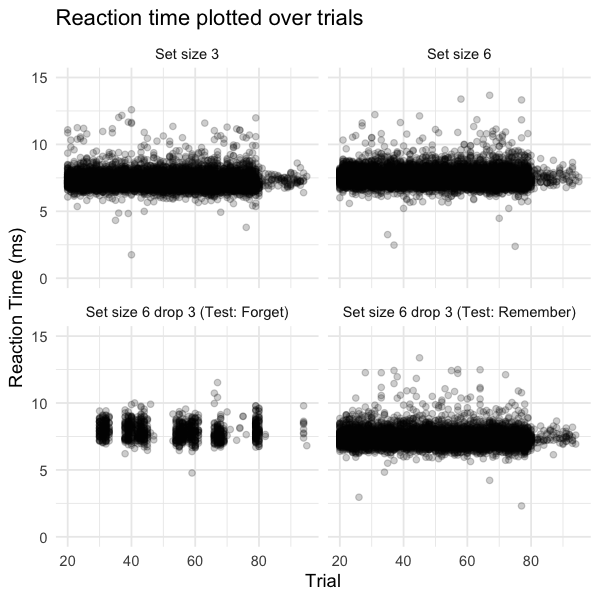

In [94]:
library(ggplot2)

raw_df %>% 
mutate(
  final_condition = paste0(surprise, '_', condition),
  final_condition = recode(final_condition, 
  'no_difo_3' = "Set size 3",
  'no_difo_6-3' = "Set size 6 drop 3 (Test: Remember)",
  'difo_6-3' = "Set size 6 drop 3 (Test: Forget)",
  'no_difo_6' = "Set size 6"),
  log_rt = log(rt))%>%
ggplot(aes(x = trial_index, y = log_rt)) +
  geom_point(alpha = 0.2) +
  facet_wrap(~ final_condition) +
  labs(title = "Reaction time plotted over trials",
  x = "Trial", y = "Reaction Time (ms)") +
  scale_y_continuous(limits = c(0, 15))+
  theme_minimal()

I plotted log reaction time data before applying any corrections to the data. Based on visual inspection, the data show a wide variability of RTs.

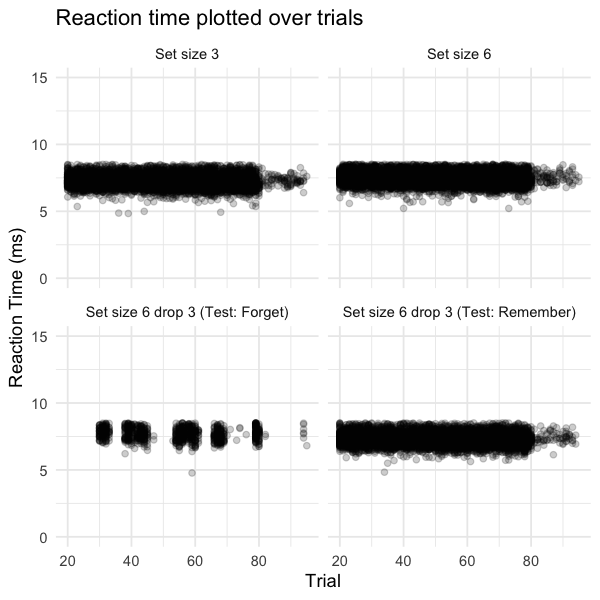

In [95]:
clean_rt_plot <- cleaned_df %>% 
mutate(final_condition = recode(final_condition, 
  'no_difo_3' = "Set size 3",
  'no_difo_6-3' = "Set size 6 drop 3 (Test: Remember)",
  'difo_6-3' = "Set size 6 drop 3 (Test: Forget)",
  'no_difo_6' = "Set size 6"))%>%
ggplot(aes(x = trial_index, y = log_rt)) +
  geom_point(alpha = 0.2) +
  facet_wrap(~ final_condition) +
  labs(title = "Reaction time plotted over trials",
  x = "Trial", y = "Reaction Time (ms)") +  
  scale_y_continuous(limits = c(0, 15))+
  theme_minimal()

clean_rt_plot

In contrast to the previous plot, RT has less variability after data were cleaned. To examine RTs more closely, I changed the y-limits of the plot.

Scale for y is already present.
Adding another scale for y, which will replace the existing scale.


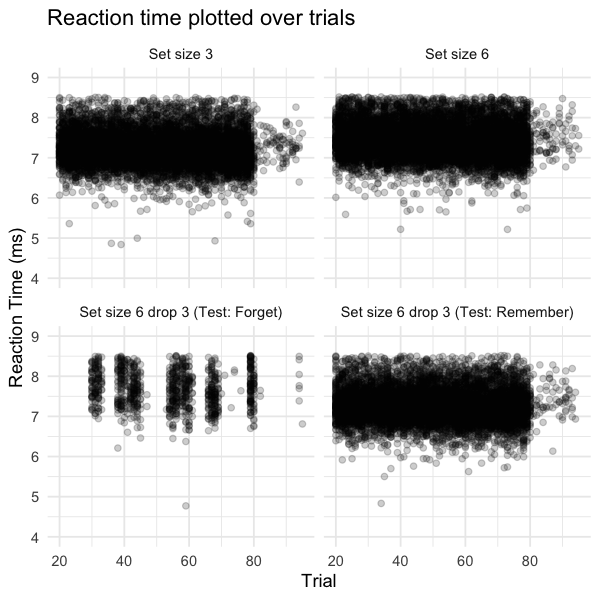

In [96]:
clean_rt_plot + scale_y_continuous(limits = c(4, 9))

Overall, reaction times are expected to be faster with lower working memory loads since participants would have fewer items in working memory to compare against at test. Based on visual insepction, log reaction time for set size 3 is the lowest out of all three conditions, followed by set size 6 drop 3 - test remember. Log reaction time were the highest for set size 6 and on the set size 6 drop 3 - test forget condition. Data from the set size 6-3 test forget condition occured on some trials for 'forget' words. Overall, reaction time data suggest that working memory load at set size 3 might be the lowest, followed by set size 6 drop 3 remember, and set size 6. Given the limited data for set size 6 drop 3 forget, no conclusive interpretation can be drawn.

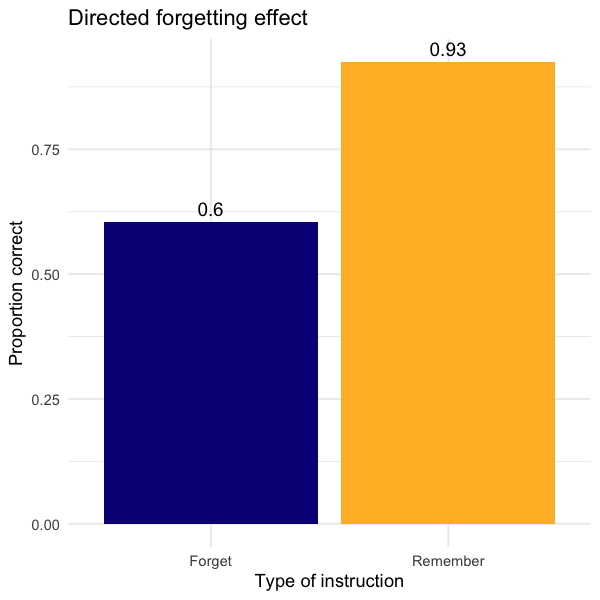

In [97]:
# check for directed forgetting effect
library(viridis)
cleaned_df %>%
filter(condition == '6-3')%>%
mutate(surprise = recode(surprise,
    'difo' = 'Forget',
    'no_difo' = 'Remember')) %>%
    mutate(surprise = as.factor(surprise))%>%
    group_by(surprise)%>%
    summarize(mean_accuracy = mean(correct))%>%
    ggplot(aes(x = surprise, y = mean_accuracy, fill = surprise)) +
    geom_col(position = position_dodge(0.8)) +
    labs(title = 'Directed forgetting effect',
        x = "Type of instruction",
        y = "Proportion correct") +
    scale_fill_viridis_d(option = "C", end = 0.85) +
    geom_text(aes(label = round(mean_accuracy, 2)), 
            position = position_dodge(0.8), 
            vjust = -0.5, size = 4)+
            theme_minimal()+
            theme(legend.position = "none")


Accuracy from the set size 6 drop 3 condition was plotted. Participants demonstrated the directed forgetting effect - accuracy was lower for words that participants were told to forget, in comparison to words that participants were told to remember. The results show that participants followed instructions and were able to forget when directed to.

## Section 1: Replicating analyses

Accuracy is predicted by condition:
$$
Y_{accuracy} = \beta_0 + \beta_1 X_{condition} + e_{subject}
$$

Given contemporary discussions in replication within Psychology, I set out to replicate their findings on two fronts. First, I conducted a Bayesian analysis to see if I arrived at the same results as the original authors. Then, I tested with same hypothesis via null hypothesis testing (NHTS) to see if the results from NHTS converged with the Bayesian analysis.

### 1.1. Linear mixed model: Bayesian analysis

In [98]:
library(BayesFactor)

In [99]:
#remove 'test: forget' conditions
remember_only_df <- cleaned_df%>%
    filter(final_condition != 'difo_6-3')%>%
    mutate(trial_num_f = scale(trial_num, scale = F))%>%
    filter(trial_before != 'difo_6-3') #ensure that trial before is not a 'forget' trial

h1_df <- remember_only_df %>%
    filter(final_condition != 'no_difo_6')

h2_df <- remember_only_df %>%
    filter(final_condition != 'no_difo_3')


#### 1.1.1. H1: Set size 3 and set size 6-3 will not differ in terms of accuracy.

In [100]:
#get descriptives of the dataframe
h1_df%>%
group_by(final_condition)%>%
summarize(mean_accuracy = mean(correct),
sd_accuracy = sd(correct))

final_condition,mean_accuracy,sd_accuracy
<chr>,<dbl>,<dbl>
no_difo_3,0.9418367,0.2340652
no_difo_6-3,0.9248971,0.2635742


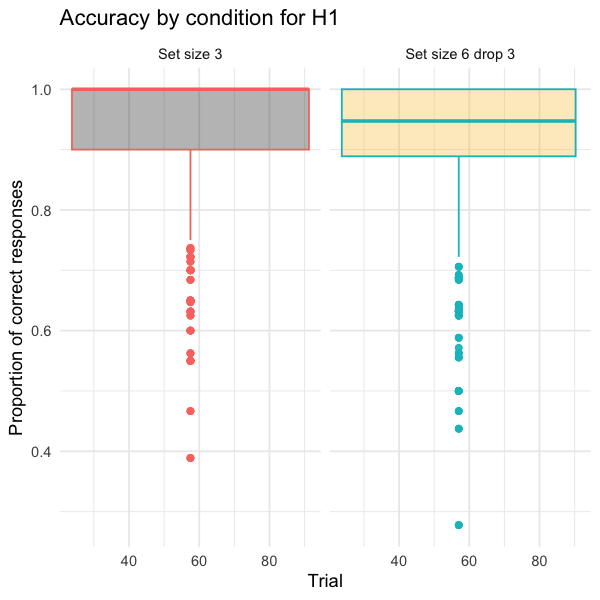

In [101]:
cleaned_df %>% 
filter(condition != 6)%>%
mutate(condition = recode(condition, 
'3' = "Set size 3",
'6-3' = "Set size 6 drop 3"))%>%
filter(surprise == 'no_difo')%>%
group_by(subject, condition)%>%
mutate(proportion_correct = mean(correct)) %>%
ggplot(aes(x = trial_index, y = proportion_correct)) +
  geom_boxplot(aes(color = condition, fill = condition), alpha = 0.3) +  # Create boxplot with condition color
  facet_wrap(~ condition) +
  labs(title = 'Accuracy by condition for H1',
        x = "Trial",
        y = "Proportion of correct responses") +
  scale_fill_viridis_d(option = "B", end = 0.85) +
  #scale_color_viridis_d(option = "B") + 
  theme_minimal()+
  theme(legend.position = "none")

Accuracy is comparable for set size 3 and set size 6-3. Based solely on visual inspection, the data seem to provide evidence in support of H1.

Moving on to the Bayesian analysis, the two hypotheses in the analyses are as follows:

H1: Correct responses are predicted by condition (set size 3 and set size 6-3) and trial number.

H0: Correct responses are predicted by trial number.

In [102]:
h1_full_mod <- lmBF(
    correct ~ final_condition + trial_num_f,
    data = h1_df,
    whichRandom = "subject")

h0_mod <- lmBF(
    correct ~ trial_num_f,
    data = h1_df,
    whichRandom = "subject") #no set size

h1_hy_output <- h1_full_mod/h0_mod

In [ ]:
h1_hy_output

Bayes factor analysis
--------------
[1] final_condition + trial_num_f : 271.4615 <U+00B1>4.97%

Against denominator:
  correct ~ trial_num_f 
---
Bayes factor type: BFlinearModel, JZS


In [104]:
# to determine which condition is better
posterior_samples <- posterior(h1_full_mod, iterations = 10000)
colnames(posterior_samples)

[1] "mu"                          "final_condition-no_difo_3"  
[3] "final_condition-no_difo_6-3" "trial_num_f-trial_num_f"    
[5] "sig2"                        "g_final_condition"          
[7] "g_continuous"

In [105]:
mean(posterior_samples[, "final_condition-no_difo_3"])
# value is positive, therefore set size 3 accuracy > set size 6-3

[1] 0.008505432

Based on the results of the analysis, there is strong evidence favoring H1 over H0. The results suggest that having condition as a main effect might explain the data better than not including the main effect at all. Considering the mean calculation of the posterior, accuracies in set size 3 conditions are better than accuracies in set size 6-3.

This finding goes against what was reported in Dames and Oberauer's experiment 1 analysis, where the authors reported that the evidence provided by the Bayes factor was ambiguous (BF = 1.0). 

#### 1.1.2. H2: Set size 6-3 will have higher accuracy than set size 6.

In [106]:
#get descriptives of the dataframe
h2_df%>%
group_by(final_condition)%>%
summarize(
    mean_accuracy = mean(correct),
    sd_accuracy = sd(correct))

final_condition,mean_accuracy,sd_accuracy
<chr>,<dbl>,<dbl>
no_difo_6,0.8472254,0.3597909
no_difo_6-3,0.9248971,0.2635742


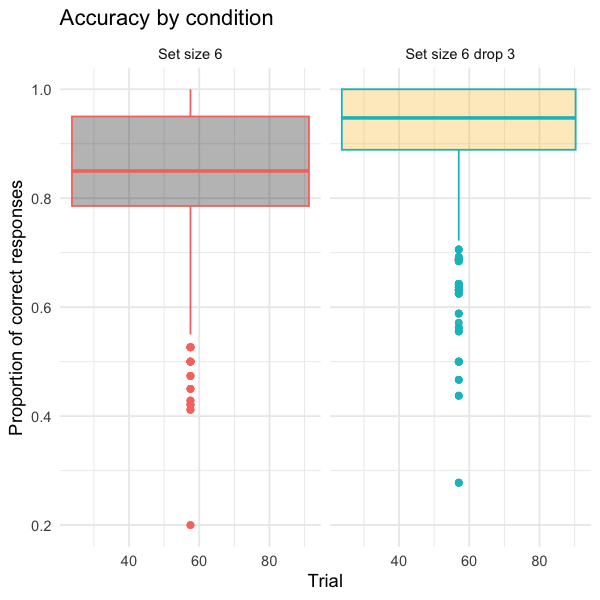

In [107]:
cleaned_df %>% 
filter(condition != 3)%>%
mutate(condition = recode(condition, 
'6-3' = "Set size 6 drop 3",
'6' = "Set size 6"))%>%
filter(surprise == 'no_difo')%>%
group_by(subject, condition)%>%
mutate(proportion_correct = mean(correct)) %>%
ggplot(aes(x = trial_index, y = proportion_correct)) +
  geom_boxplot(aes(color = condition, fill = condition), alpha = 0.3) +  # Create boxplot with condition color
  facet_wrap(~ condition) +
  labs(title = 'Accuracy by condition',
        x = "Trial",
        y = "Proportion of correct responses") +
  scale_fill_viridis_d(option = "B", end = 0.85) +
  #scale_color_viridis_d(option = "B") + 
  theme_minimal()+
  theme(legend.position = "none")

Accuracy for set size 6 is lower than accuracy for set size 6-3. Based solely on visual inspection, the data seem to provide evidence in support of H2. 

Moving on to the Bayesian analysis, the two hypotheses in the analyses are as follows:

H2: Correct responses are predicted by condition (set size 6 and set size 6-3) and trial number.

H0: Correct responses are predicted by trial number.

In [108]:
h2_full_mod <- lmBF(
    correct ~ final_condition + trial_num,
    data = h2_df,
    whichRandom = "subject")

h2_0_mod <- lmBF(
    correct ~ trial_num, 
    data = h2_df, 
    whichRandom = "subject") #no set size
    
h2_hy_output <- h2_full_mod/h2_0_mod

In [109]:
h2_hy_output

Bayes factor analysis
--------------
[1] final_condition + trial_num : 6.653477e+50 <U+00B1>1.43%

Against denominator:
  correct ~ trial_num 
---
Bayes factor type: BFlinearModel, JZS


In [138]:
posterior_samples <- posterior(h2_full_mod, iterations = 10000)
colnames(posterior_samples)

[1] "mu"                          "final_condition-no_difo_6"  
[3] "final_condition-no_difo_6-3" "trial_num-trial_num"        
[5] "sig2"                        "g_final_condition"          
[7] "g_continuous"

In [139]:
mean(posterior_samples[, "final_condition-no_difo_6"])

[1] -0.03880264

Based on the results of the analysis, there is strong evidence favoring H2 over H0. The results suggest that there is a difference between the likelihood of correctly identifying the location of the probe stimulus when considering set size 6-3 and set size 6, compared to when considering trial number alone. Mean accuracy is lower for set size 6 than set size 6-3.

My findings support what was reported in Dames and Oberauer's experiment 1 analysis, where the authors reported that the evidence provided by the Bayes factor was not ambiguous  (BF10 = 1.2 × 1026).

### 1.2. Linear regression: Null hypothesis statistical test

In [119]:
# linear mixed effects with random effects
library(lme4)
library(lmerTest)


Attaching package: 'lmerTest'


The following object is masked from 'package:lme4':

    lmer


The following object is masked from 'package:stats':

    step




In [120]:
mod1_nhst <- lmer(
    correct ~ final_condition + (1|subject) + trial_num_f,
    data = h1_df)

summary(mod1_nhst)

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: correct ~ final_condition + (1 | subject) + trial_num_f
   Data: h1_df

REML criterion at convergence: -156.5

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-4.1668  0.0768  0.1416  0.3014  1.9683 

Random effects:
 Groups   Name        Variance Std.Dev.
 subject  (Intercept) 0.006718 0.08196 
 Residual             0.055225 0.23500 
Number of obs: 16596, groups:  subject, 470

Fixed effects:
                             Estimate Std. Error         df t value Pr(>|t|)
(Intercept)                 9.399e-01  4.536e-03  6.235e+02 207.191  < 2e-16
final_conditionno_difo_6-3 -1.680e-02  3.660e-03  1.613e+04  -4.591 4.45e-06
trial_num_f                -1.403e-04  1.057e-04  1.621e+04  -1.326    0.185
                              
(Intercept)                ***
final_conditionno_difo_6-3 ***
trial_num_f                   
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' '

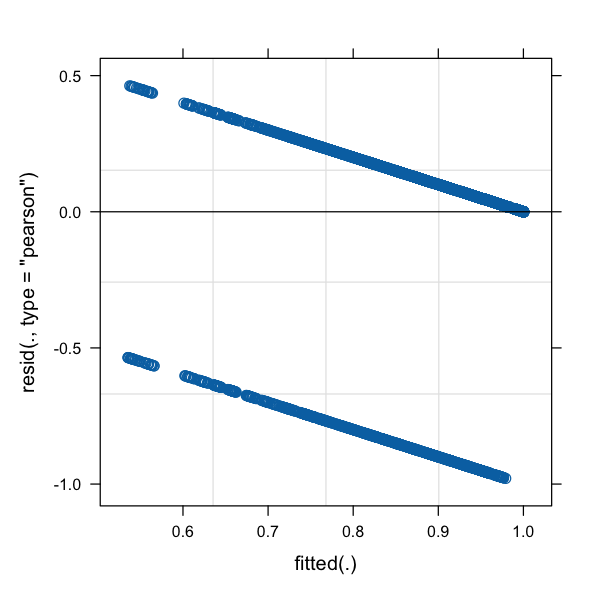

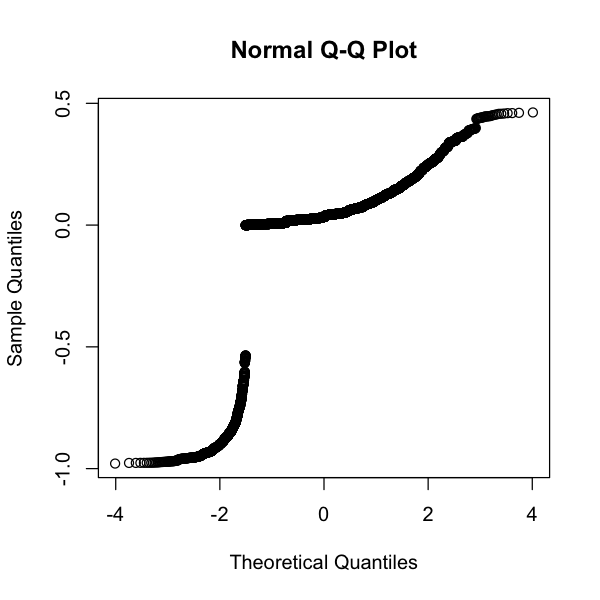

In [121]:
# check assumptions
plot(mod1_nhst, which = 1)
qqnorm(resid(mod1_nhst))

There is a main effect of condition, with worse accuracy performance occuring for the set size 6-3 condition. However, while this result is significant, upon checking the residuals of the model, I observed deviations from a normal distribution. As such, I would go with the Bayes Factors results and not the NHTS results.

In [122]:
mod2_nhst <- lmer(
    correct ~ final_condition + (1|subject) + trial_num_f,
    data = h2_df)

summary(mod2_nhst)

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: correct ~ final_condition + (1 | subject) + trial_num_f
   Data: h2_df

REML criterion at convergence: 8326.1

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-3.2519  0.0877  0.2819  0.4459  1.8501 

Random effects:
 Groups   Name        Variance Std.Dev.
 subject  (Intercept) 0.007818 0.08842 
 Residual             0.093405 0.30562 
Number of obs: 16390, groups:  subject, 470

Fixed effects:
                            Estimate Std. Error        df t value Pr(>|t|)    
(Intercept)                8.454e-01  5.248e-03 6.926e+02 161.084   <2e-16 ***
final_conditionno_difo_6-3 7.783e-02  4.787e-03 1.594e+04  16.258   <2e-16 ***
trial_num_f                3.504e-05  1.385e-04 1.603e+04   0.253      0.8    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Correlation of Fixed Effects:
            (Intr) f___6-
fnl_cn__6-3 -0.432       
trial_num_f -0.005  0.013

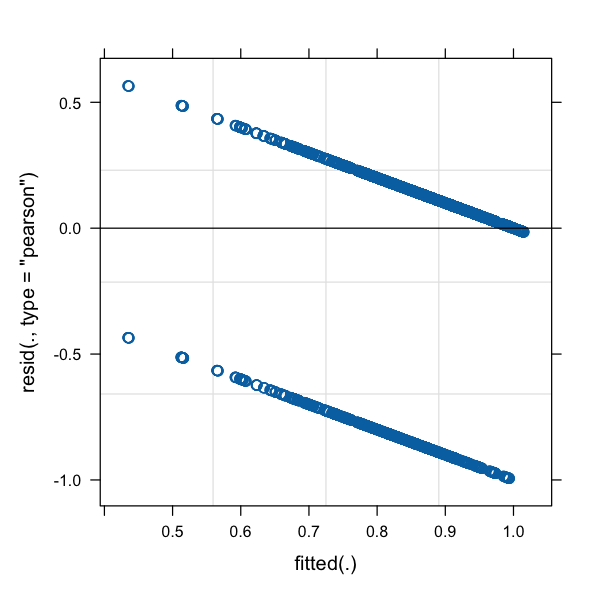

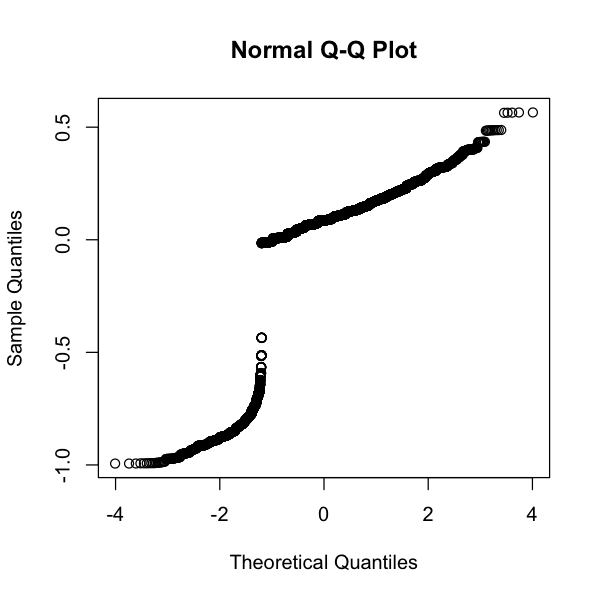

In [123]:
# check assumptions
plot(mod2_nhst, which = 1)
qqnorm(resid(mod2_nhst))

There is a main effect of condition, with *better* accuracy performance occuring for the set size 6-3 condition than for the set size 6 condition. However, while this result is significant, upon checking the residuals of the model, as with the previous model, I observed deviations from a normal distribution. As such, I would go with the Bayes Factors results and not the NHTS results.

## Section 2: Data exploration

Statistical analyses for *behavioral* working memory typically focus on means-difference testing between groups. Here, I was interested in exploring the data with two techniques. 

Firstly, to account for random effects that might influence the data, I conducted a linear mixed effects model. In this analysis, I conducted an omnibus model - a notable change from other analyses examining evidence for H1 and H2. I combined all three conditions - set size 3, set size 6-3, and set size 6 to compare all effects at once. The variables I chose to include in addition to condition were: probe position (position of the word tested), subject, word tested, and trial number as random effects. Probe position can influence working memory via primary and recency effects, where memory for first and last items respectively, are better than that for words presented in the middle of the sequence. Working memory varies in terms of individual differences, thus its inclusion in my model under 'subject'. While words tested and trial number (i.e., how far along in the experiment participants are) should not have systematic influence on accuracy, these measures were included to test this assumption. 

Secondly, I used K-nearest neighbors classifiers to apply a data-driven approach to accuracy measures. Using only condition and accuracy, I sought to determine if KNN classifiers could categorize accuracy performance into different set sizes independently. If KNN classifiers identified subgroups of accuracy performance that lined up with the conditions, then different cognitive processes could be employed in each of these conditions. 


Accuracy is predicted by condition, probe position, trial, and subject slopes:
$$
Y_{accuracy} = \beta_0 + \beta_1 X_{condition} + \beta_1 X_{trial number} + e_{subject} + e_{probe position}
$$

### 2.1. Full random effects model

In [124]:
rand_fix_fx <- lmer(
    correct ~ final_condition + trial_num_f + (1|probe_position) + (1|subject) + (1|probe_word),
    data = remember_only_df)
    
summary(rand_fix_fx)

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: correct ~ final_condition + trial_num_f + (1 | probe_position) +  
    (1 | subject) + (1 | probe_word)
   Data: remember_only_df

REML criterion at convergence: 8006.7

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-3.6674  0.0436  0.2256  0.4356  1.9992 

Random effects:
 Groups         Name        Variance  Std.Dev.
 probe_word     (Intercept) 5.493e-05 0.007411
 subject        (Intercept) 7.110e-03 0.084323
 probe_position (Intercept) 4.216e-04 0.020534
 Residual                   7.760e-02 0.278559
Number of obs: 25210, groups:  probe_word, 600; subject, 470; probe_position, 6

Fixed effects:
                             Estimate Std. Error         df t value Pr(>|t|)
(Intercept)                 9.397e-01  9.719e-03  8.196e+00  96.687 7.99e-14
final_conditionno_difo_6   -9.469e-02  4.240e-03  2.474e+04 -22.336  < 2e-16
final_conditionno_difo_6-3 -1.652e-02  4.339e-03  2.474

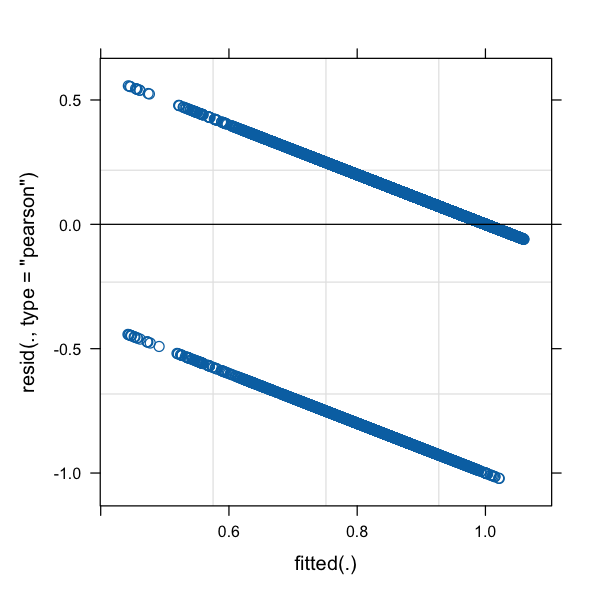

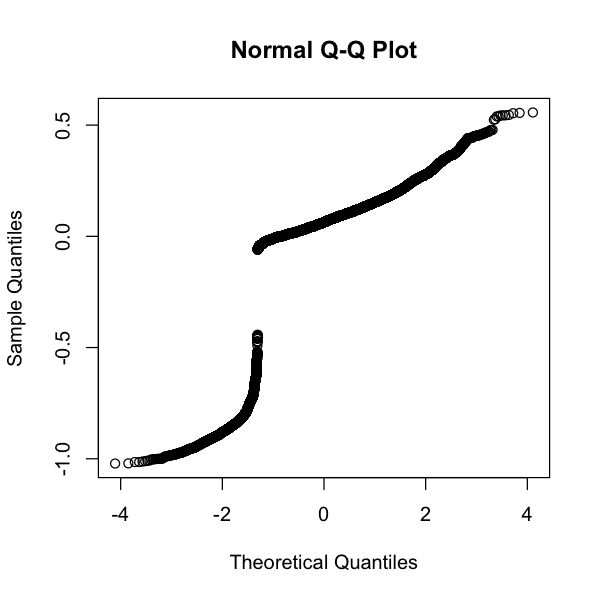

In [125]:
# check assumptions
plot(rand_fix_fx, which = 1)
qqnorm(resid(rand_fix_fx))

After considering additional random effects, accuracy performance seems to be highest for set size 3, followed by set size 6-3 condition, and lastly the set size 6 condition. Again, while this result is significant, upon checking the residuals of the model, as with the previous NHTS results, I observed deviations from a normal distribution, suggesting that other forms of analyses need to be run alongside this model.

### 2.2. K-Nearest Neighbors Classifier

In [126]:
library(class)
set.seed(1) 

#trying to scale data
scaled_data <- cleaned_df %>%
  mutate(
    correct = scale(correct),
    log_rt = scale(log_rt),
    final_condition_num = as.numeric(as.factor(final_condition))
  )

#pull random sample of 40 row indices - 10 per condition
sampled_data <- scaled_data %>%
  group_by(final_condition) %>%
  slice_sample(n = 10) %>%
  ungroup()

In [127]:
#output
train_x <- anti_join(scaled_data, sampled_data)%>%
    select("correct", "log_rt")
test_x <- semi_join(scaled_data, sampled_data)%>%
    select("correct", "log_rt")

#response variable
train_y <- anti_join(scaled_data, sampled_data) %>%
  pull(final_condition_num)
test_y <- semi_join(scaled_data, sampled_data) %>%
  pull(final_condition_num)

Joining with `by = join_by(trial_index, exp_part, subject, rt, correct,
key_match, key_mismatch, group, key_press, words, trial_num, condition,
forget_conditions, probe_cond, surprise, probe_word, probe_position, log_rt,
final_condition, trial_before, final_condition_num)`
Joining with `by = join_by(trial_index, exp_part, subject, rt, correct,
key_match, key_mismatch, group, key_press, words, trial_num, condition,
forget_conditions, probe_cond, surprise, probe_word, probe_position, log_rt,
final_condition, trial_before, final_condition_num)`
Joining with `by = join_by(trial_index, exp_part, subject, rt, correct,
key_match, key_mismatch, group, key_press, words, trial_num, condition,
forget_conditions, probe_cond, surprise, probe_word, probe_position, log_rt,
final_condition, trial_before, final_condition_num)`
Joining with `by = join_by(trial_index, exp_part, subject, rt, correct,
key_match, key_mismatch, group, key_press, words, trial_num, condition,
forget_conditions, probe_cond, sur

In [128]:
library(purrr)
set.seed(1) 

k <- seq(1, 20, 1)
k_pred_fx <- function(i){
    knn_pred <- knn(train = train_x, test = test_x, cl = train_y, k = i)
    knn_result <- knn_pred == test_y
    prob <- sum(knn_result == TRUE)/length(knn_result)
    return(data.frame(k = i, prob = prob))
}

results_df <- map_dfr(k, k_pred_fx) #this will return K and its associated prediction accuracy.
head(results_df)

,k,prob
,<dbl>,<dbl>
1,1,0.25
2,2,0.30
3,3,0.25
4,4,0.25
5,5,0.30
6,6,0.30


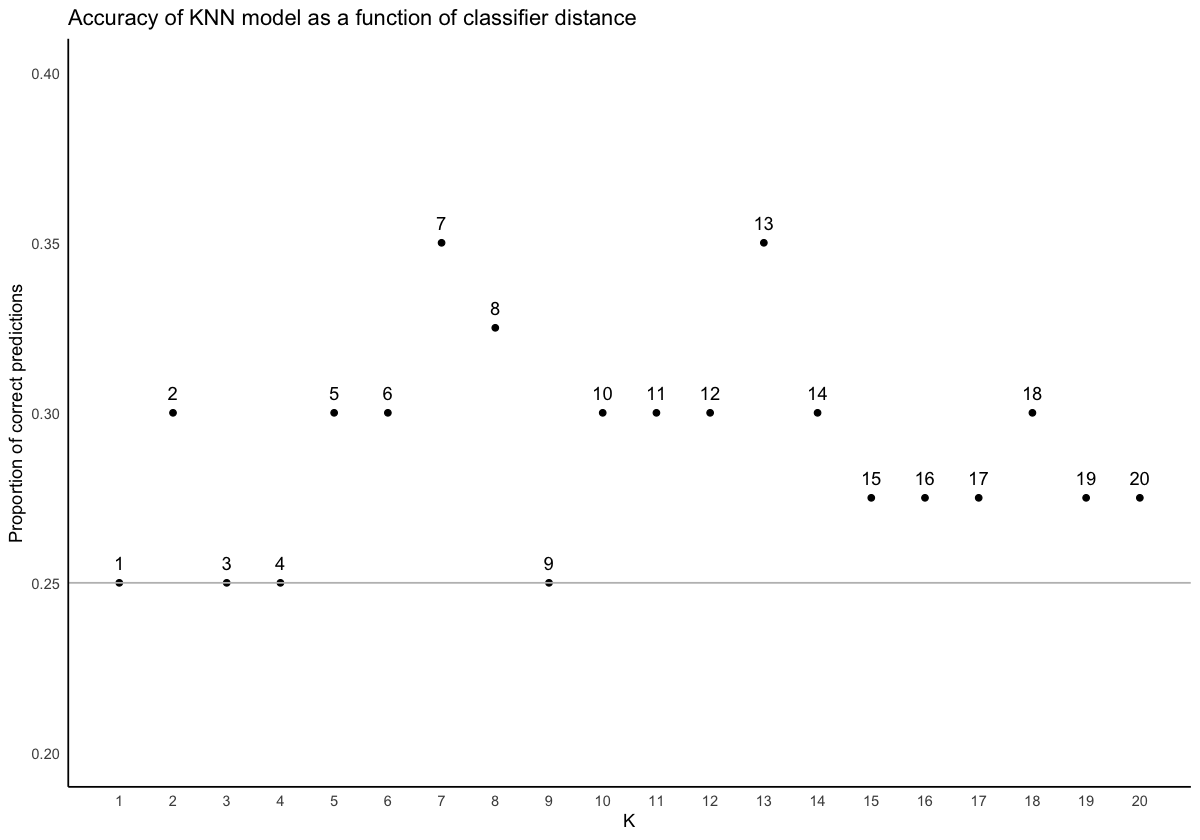

In [129]:
options(repr.plot.width = 10, repr.plot.height = 7)

results_df %>%
ggplot(aes(x=k, y=prob)) + 
    geom_point() + 
      geom_text(aes(label = k), vjust = -1) +  # adjust vjust as needed
      scale_x_continuous(breaks = seq(min(results_df$k), max(results_df$k), by = 1)) +
       labs(title = 'Accuracy of KNN model as a function of classifier distance',
        x = "K",
        y = "Proportion of correct predictions") +
        geom_hline(yintercept = 0.25, color = "grey") + # since there are 4 conditions, draw line at chance
        scale_y_continuous(limits = c(0.2, 0.4)) +
    theme_minimal() +
    theme(
      panel.grid.major = element_blank(),
      panel.grid.minor = element_blank(),
      axis.line = element_line(color = "black"),
      panel.border = element_blank()
    )

The kNN classifier had to identify if a data point belonged to one of four conditions, meaning chance performance was at 25% (or 0.25 in proportion). Generally, the kNN classifier performed at just above chance, with a classifying accuracy staying between 0.25 to 0.3, regardless of the value of K. The graph suggests that the proportion of correctly predicted accuracy scores does not scale according to K. Interestingly, the highest prediction accuracies come from K = 7 and 13, which could indicate the importance of increasing the bias for 

## Section 3: Power Analysis for Sample Size Estimation

A power analysis was conducted using the full model with random effects on simulated data to determine the number of participants required for a replication of the study. Since there were two linear regressions run, I conducted 2 power analyses. I decided to use the sample size and trial numbers from the original authors with one caveat. The authors required high sample size numbers due to the limited number of times they could test 'forget' words - once, twice, or four times. Since my study will test participants on 'forget' words only thrice, I created a simulated dataset using the sample size of the 'four times' condition - N = 120. The authors also employed 20 trials per set size condition, which I used in the power analysis.

### 3.1 Set size 3 and set size 6-3

In [130]:
# Simulate dataset based off fixed and random intercepts.
simulate_df <- function(
    n_subjects, n_trials,
    intercept, intercept_sd,
    slope_x, slope_x_sd,
    trial_sd) {
    
    # draw observation from a normal distribution
    subject_intercepts <- rnorm(n_subjects, intercept, intercept_sd) 
    subject_slope_x <- rnorm(n_subjects, slope_x, slope_x_sd)
    
    dat <- data.frame(
        subject = 1:n_subjects,
        intercept = subject_intercepts,
        slope_x = subject_slope_x)

    dat <- dat %>%
    tidyr::uncount(weights = n_trials) %>%
    group_by(subject) %>%
    mutate(
        trial = row_number(),
        probe_position = rep(1:6, length.out = n_trials)  # random 1-6
    ) %>%
    ungroup()%>%
    rowwise() %>%
    mutate(
    base_cond = list(rnorm(n_trials, intercept, trial_sd)),
    compare_cond = list(rnorm(n_trials, intercept + slope_x, trial_sd))
    )%>%
    ungroup() %>%
    mutate(id = row_number()) %>%
    select(id, everything()) %>%
    tidyr::pivot_longer(
    cols = ends_with("cond"),
    names_to = "condition",
    values_to = "values")%>%
    tidyr::unnest(values)%>%
    select(-starts_with(c('slope', 'intercept')))
    
    return(dat)
}

In [131]:
run_analysis <- function(df){
    mod <- lmer(
    values ~ condition + trial + (1|subject),
    data = df)
    }

In [132]:
library(simr)
ss3_sim_df <- simulate_df(n_subjects = 120, n_trials = 20,
    intercept = 9.399e-01, intercept_sd = 4.536e-03,
    slope_x = -1.680e-02, slope_x_sd = 3.660e-03,
    trial_sd = 1.057e-04)

In [133]:
head(ss3_sim_df)

id,subject,trial,probe_position,condition,values
<int>,<int>,<int>,<int>,<chr>,<dbl>
1,1,1,1,base_cond,0.9295798
1,1,1,1,base_cond,0.9294273
1,1,1,1,base_cond,0.9297135
1,1,1,1,base_cond,0.9297034
1,1,1,1,base_cond,0.9293727
1,1,1,1,base_cond,0.9295123


In [134]:
mod_1 <- run_analysis(ss3_sim_df)
powerSim(mod_1)

Simulating: |                                                                 Simulating: |=                                                                Simulating: |==                                                               Simulating: |===                                                              Simulating: |====                                                             Simulating: |=====                                                            Simulating: |======                                                           Simulating: |=======                                                          Simulating: |========                                                         Simulating: |=========                                                        Simulating: |==========                                                       Simulating: |===========                                                      Simulating: |============                                       

Warning message in observedPowerWarning(sim):
"This appears to be an "observed power" calculation"


Power for predictor 'condition', (95% confidence interval):
      100.0% (99.63, 100.0)

Test: unknown test

Based on 1000 simulations, (0 warnings, 0 errors)
alpha = 0.05, nrow = 96000

Time elapsed: 0 h 19 m 41 s

nb: result might be an observed power calculation

In [135]:
intercept <- 8.454e-01
intercept_sd <- 5.248e-03
slope_x <- 7.783e-02
slope_x_sd <- 4.787e-03
trial_sd <- 1.385e-04

ss6_sim_df <- simulate_df(
    n_subjects = 120, n_trials = 20,
    intercept, intercept_sd,
    slope_x, slope_x_sd,
    trial_sd)

In [136]:
head(ss6_sim_df)

id,subject,trial,probe_position,condition,values
<int>,<int>,<int>,<int>,<chr>,<dbl>
1,1,1,1,base_cond,0.8409256
1,1,1,1,base_cond,0.8409868
1,1,1,1,base_cond,0.8408488
1,1,1,1,base_cond,0.8410860
1,1,1,1,base_cond,0.8410469
1,1,1,1,base_cond,0.8407969


In [137]:
mod_2 <- run_analysis(ss6_sim_df)
powerSim(mod_2)

Simulating: |                                                                 Simulating: |=                                                                Simulating: |==                                                               Simulating: |===                                                              Simulating: |====                                                             Simulating: |=====                                                            Simulating: |======                                                           Simulating: |=======                                                          Simulating: |========                                                         Simulating: |=========                                                        Simulating: |==========                                                       Simulating: |===========                                                      Simulating: |============                                       

Warning message in observedPowerWarning(sim):
"This appears to be an "observed power" calculation"


Power for predictor 'condition', (95% confidence interval):
      100.0% (99.63, 100.0)

Test: unknown test

Based on 1000 simulations, (0 warnings, 0 errors)
alpha = 0.05, nrow = 96000

Time elapsed: 0 h 23 m 23 s

nb: result might be an observed power calculation

Since the power analyses for both conditions demonstrate that there is more than sufficient power in the selected sample sizes and experiment designs to observe a significant, I decided to employ the chosen sample sizes of N = 120 for my upcoming study. 

## Conclusions

In this final project, I had 2 main hypotheses: H1 - set size 3 and set size 6-3 will not differ in accuracy, and H2 - set size 6-3 will have higher accuracy than set size 6. To examine my hypotheses and explore the data, I had three sections with their separate aims. 

In my first section, I attempted to replicate the authors’ analysis by comparing bayesian factors on a mixed effects model. I found that set size 3 and set size 6-3 differed in accuracy relative to the null model, with accuracies in set size 3 being higher than set size 6-3. This diverged from the authors’ original results. For the second hypothesis, my results converged with that of the authors - that H2 accounted for the data better than H0, and that set size 6 has lower accuracy than set size 6-3. Given contemporary discussions surrounding p-values in NHTS and Bayesian analysis, I ran the same mixed effects models but with an NHST approach. Both findings from the NHTS and Bayesian approach supported each other, providing support for H1 and H2 over H0. 

In my second section, I wanted to deviate from traditional analyses in working memory. I employed a full mixed effects model, and added random effects that are typically ignored in working memory research. I included probe position and word tested, alongside subject and trial number. Overall, the results support a main effect of condition, even after considering the influence of additional random effects. I was also interested in employing a classifier that could determine which condition accuracy data belonged to. However, after using kNN, I did not observe a meaningful relationship between K and prediction accuracy.

In my third and final section, I conducted 2 power analyses with the intercepts and slopes from H1 and H2 mixed effects models to determine an appropriate sample size for a replication study. The analyses suggested that a sample size of 120 and 20 trials per condition might be sufficient to detect my desired effect. 

In conclusion, set size 3, 6, and 6-3 differ in their accuracy rates. Based on my first section, the highest accuracy is driven by trials in the set size 3 condition, as expected when working memory loads are low. Set size 6 has low accuracy, since working memory load is high. Finally, accuracy for set size 6-3 falls between set size 3 and set size 6, providing further support for the facilitated effect where direct forgetting benefits memory relative to baseline performance for high working memory load.

# References

Dames, H., & Oberauer, K. (2022). Directed forgetting in working memory. Journal of Experimental Psychology: General, 151(12), 2990–3008. https://doi.org/10.1037/xge0001256

Ecker, U. K. H., Lewandowsky, S., & Oberauer, K. (2014). Removal of information from working memory: A specific updating process. Journal of Memory and Language, 74, 77–90. https://doi.org/10.1016/j.jml.2013.09.003

Fawcett, J. M., & Taylor, T. L. (2012). The control of working memory resources in intentional forgetting: Evidence from incidental probe word recognition. Acta Psychologica, 139(1), 84–90. https://doi.org/10.1016/j.actpsy.2011.10.001

Festini, S. B., & Reuter-Lorenz, P. A. (2017). Rehearsal of to-be-remembered items is unnecessary to perform directed forgetting within working memory: Support for an active control mechanism. Journal of Experimental Psychology: Learning, Memory, and Cognition, 43(1), 94–108. https://doi.org/10.1037/xlm0000308

Lewis‐Peacock, J. A., Kessler, Y., & Oberauer, K. (2018). The removal of information from working memory. Annals of the New York Academy of Sciences, 1424(1), 33–44. https://doi.org/10.1111/nyas.13714

Oberauer, K. (2018). Removal of irrelevant information from working memory: Sometimes fast, sometimes slow, and sometimes not at all. Annals of the New York Academy of Sciences, 1424(1), 239–255. https://doi.org/10.1111/nyas.13603

Oberauer, K., & Lewandowsky, S. (2014). Further evidence against decay in working memory. Journal of Memory and Language, 73, 15–30. https://doi.org/10.1016/j.jml.2014.02.003

Popov, V., Marevic, I., Rummel, J., & Reder, L. M. (2019). Forgetting Is a Feature, Not a Bug: Intentionally Forgetting Some Things Helps Us Remember Others by Freeing Up Working Memory Resources. Psychological Science, 30(9), 1303–1317. https://doi.org/10.1177/0956797619859531
